# Google Play Reviews and Developer Response Analysis

## Business question

**How can an app company understand customer dissatisfaction, improve review-response performance, and identify reviews that require attention?**

In this project, I analyse Google Play reviews to understand customer ratings and how the developer responds to users. I also build a simple machine learning model to see whether the information in a review can help predict if the developer will respond. The project includes:

- data quality assessment,
- transparent data cleaning,
- advanced feature engineering,
- customer experience analysis,
- developer-response performance,
- operational prioritisation,
- machine-learning model comparison,
- model interpretation,
- and Power BI-ready exports.

The dataset contains **161 Google Play reviews** spanning **2016-08-31 to 2024-09-03**.

## 1. Imports and reproducibility

The project uses a fixed random seed where relevant so that model comparisons are reproducible.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 2. Load the raw data

In [2]:
DATA_PATH = Path("..") / "data" / "raw" / "GooglePlay_App_Data.csv"
reviews = pd.read_csv(DATA_PATH)
print(f"Rows: {reviews.shape[0]:,}")
print(f"Columns: {reviews.shape[1]}")
reviews.head()

Rows: 161
Columns: 12


,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code
0,81942ead-9d65-4b1a-8aa2-6e21ad5cf5e7,Vernalee Fortin,NaN,"Still loving it!, the best!",5,0,9/3/2024 0:23,NaN,NaN,23.12.04000,en,us
1,c08cf1e7-45e4-43a3-b86f-51f7809b80a3,Toki Doki,NaN,Convenient one stop app for all your passwords...,5,0,8/19/2024 3:32,NaN,NaN,23.12.04000,en,us
2,c8937763-e1b4-43b1-9e48-cde58be80111,CJ Cross,NaN,Tried several password managers until I came a...,5,0,7/30/2024 8:07,NaN,NaN,23.12.04000,en,us
3,762baf4b-9109-4b4b-a42f-2291b0486faf,Trevor Lewis,NaN,Ok thank you,5,0,6/11/2024 17:20,NaN,NaN,NaN,en,us
4,275a2d36-6d77-44ae-9d7b-8be6ad614e3f,K K,NaN,switched phones and none of my passwords came ...,1,0,5/19/2024 19:20,You have to do a backup on Google Drive / Drop...,5/21/2024 23:50,23.12.04000,en,us


## 3. Dataset structure and quality

In [3]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   review_id                161 non-null    object 
 1   user_name                161 non-null    object 
 2   review_title             0 non-null      float64
 3   review_description       161 non-null    object 
 4   rating                   161 non-null    int64  
 5   thumbs_up                161 non-null    int64  
 6   review_date              161 non-null    object 
 7   developer_response       50 non-null     object 
 8   developer_response_date  50 non-null     object 
 9   appVersion               146 non-null    object 
 10  laguage_code             161 non-null    object 
 11  country_code             161 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 15.2+ KB


In [4]:
quality = pd.DataFrame({
    "dtype": reviews.dtypes.astype(str),
    "missing": reviews.isna().sum(),
    "missing_pct": (reviews.isna().mean() * 100).round(2),
    "unique": reviews.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)
quality

,dtype,missing,missing_pct,unique
review_title,float64,161,100.00,0
developer_response,object,111,68.94,37
developer_response_date,object,111,68.94,48
appVersion,object,15,9.32,19
review_description,object,0,0.00,151
user_name,object,0,0.00,62
review_id,object,0,0.00,161
rating,int64,0,0.00,5
review_date,object,0,0.00,161
thumbs_up,int64,0,0.00,15


In [5]:
print("Duplicate rows:", reviews.duplicated().sum())
print("Duplicate review IDs:", reviews["review_id"].duplicated().sum())

Duplicate rows: 0
Duplicate review IDs: 0


### What I noticed about the data

`review_title` is completely empty. I did not remove reviews with missing developer responses because, in this project, a missing response actually tells me something useful: the developer did not reply to that review.

## 4. Cleaning and date validation

In [6]:
reviews = reviews.rename(columns={"laguage_code": "language_code"}).copy()

if "review_title" in reviews.columns and reviews["review_title"].isna().all():
    reviews = reviews.drop(columns="review_title")

reviews["review_description"] = reviews["review_description"].fillna("").astype(str).str.strip()
reviews["appVersion"] = reviews["appVersion"].fillna("Unknown").astype(str)

reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")
reviews["developer_response_date"] = pd.to_datetime(
    reviews["developer_response_date"], errors="coerce"
)

reviews["has_developer_response"] = reviews["developer_response"].notna().astype(int)
reviews["response_delay_days"] = (
    reviews["developer_response_date"] - reviews["review_date"]
).dt.total_seconds() / 86400

reviews["invalid_response_delay"] = reviews["response_delay_days"] < 0
reviews.loc[reviews["invalid_response_delay"], "response_delay_days"] = np.nan

print("Rows retained:", len(reviews))
print("Invalid negative response delays flagged:", reviews["invalid_response_delay"].sum())

Rows retained: 161
Invalid negative response delays flagged: 3


Negative response delays are impossible and are treated as data-quality errors. They are set to missing **only for response-time calculations**; the review itself remains in the dataset.

## 5. Feature engineering: sentiment and reviews that may need attention

In [7]:
reviews["sentiment"] = np.select(
    [reviews["rating"] >= 4, reviews["rating"] == 3],
    ["Positive", "Neutral"],
    default="Negative"
)

reviews["needs_attention"] = (reviews["rating"] <= 3).astype(int)

reviews[["rating", "sentiment", "needs_attention"]].head()

,rating,sentiment,needs_attention
0,5,Positive,0
1,5,Positive,0
2,5,Positive,0
3,5,Positive,0
4,1,Negative,1


## 6. Feature engineering: information from the review text

In [8]:
reviews["word_count"] = reviews["review_description"].str.split().str.len()
reviews["char_count"] = reviews["review_description"].str.len()
reviews["exclamation_count"] = reviews["review_description"].str.count("!")
reviews["question_count"] = reviews["review_description"].str.count(r"\?")
reviews["uppercase_count"] = reviews["review_description"].apply(
    lambda s: sum(1 for c in s if c.isupper())
)
reviews["uppercase_ratio"] = (
    reviews["uppercase_count"] / reviews["char_count"].replace(0, np.nan)
).fillna(0)

reviews["avg_word_length"] = reviews["review_description"].apply(
    lambda s: np.mean([len(w) for w in s.split()]) if s.split() else 0
)

reviews[[
    "word_count", "char_count", "exclamation_count",
    "question_count", "uppercase_ratio", "avg_word_length"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
word_count,161.0,16.447205,20.030883,1.0,3.000000,9.000000,21.000000,97.00
char_count,161.0,86.925466,108.303483,1.0,13.000000,43.000000,116.000000,496.00
exclamation_count,161.0,0.285714,0.904355,0.0,0.000000,0.000000,0.000000,5.00
question_count,161.0,0.037267,0.271298,0.0,0.000000,0.000000,0.000000,3.00
uppercase_ratio,161.0,0.058185,0.056956,0.0,0.024096,0.037037,0.071429,0.25
avg_word_length,161.0,4.408459,1.151993,1.0,3.846154,4.305085,4.750000,10.00


## 7. Feature engineering: date and engagement features

In [9]:
reviews["review_year"] = reviews["review_date"].dt.year
reviews["review_month_num"] = reviews["review_date"].dt.month
reviews["review_month_name"] = reviews["review_date"].dt.month_name().str[:3]
reviews["review_quarter"] = "Q" + reviews["review_date"].dt.quarter.astype("Int64").astype(str)
reviews["review_dayofweek_num"] = reviews["review_date"].dt.dayofweek
reviews["review_day_name"] = reviews["review_date"].dt.day_name()
reviews["is_weekend"] = (reviews["review_dayofweek_num"] >= 5).astype(int)

reviews["thumbs_up_log"] = np.log1p(reviews["thumbs_up"])

reviews["review_length_band"] = pd.cut(
    reviews["word_count"],
    bins=[-1, 5, 20, 50, np.inf],
    labels=["Very short", "Short", "Medium", "Long"]
)

reviews["engagement_band"] = pd.cut(
    reviews["thumbs_up"],
    bins=[-1, 0, 2, 10, np.inf],
    labels=["No votes", "Low", "Medium", "High"]
)

reviews["app_version_major"] = (
    reviews["appVersion"].str.extract(r"^(\d+)")[0].fillna("Unknown")
)

## 8. Feature engineering: response time and review priority

In [10]:
reviews["response_delay_band"] = pd.cut(
    reviews["response_delay_days"],
    bins=[-np.inf, 1, 7, 30, 180, np.inf],
    labels=["Within 1 day", "2-7 days", "8-30 days", "31-180 days", "Over 180 days"]
)

reviews["responded_within_7_days"] = np.where(
    reviews["has_developer_response"].eq(1),
    (reviews["response_delay_days"] <= 7).astype(float),
    np.nan
)

# Transparent, rule-based operational score.
reviews["priority_score"] = (
    (6 - reviews["rating"]) * 20
    + np.minimum(reviews["thumbs_up"], 20) * 2
    + np.minimum(reviews["word_count"], 50) * 0.4
    + reviews["question_count"] * 4
)

reviews["priority_level"] = pd.cut(
    reviews["priority_score"],
    bins=[-np.inf, 45, 70, np.inf],
    labels=["Low", "Medium", "High"]
)

reviews["unanswered_attention_review"] = (
    (reviews["needs_attention"] == 1) &
    (reviews["has_developer_response"] == 0)
).astype(int)

I created the `priority_score` as a simple rule to help rank reviews that may need attention. It is not a machine learning prediction. I keep it separate from the actual model.

## 9. Main summary results

In [11]:
kpis = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Average rating",
        "Developer response rate",
        "Median valid response delay",
        "Reviews needing attention (1-3 stars)",
        "Unanswered attention reviews",
        "Responses within 7 days"
    ],
    "Value": [
        f"{len(reviews):,}",
        f"{reviews['rating'].mean():.2f}/5",
        f"{reviews['has_developer_response'].mean()*100:.1f}%",
        f"{reviews['response_delay_days'].median():.1f} days",
        f"{reviews['needs_attention'].sum():,}",
        f"{reviews['unanswered_attention_review'].sum():,}",
        f"{reviews.loc[reviews['has_developer_response'].eq(1), 'responded_within_7_days'].mean()*100:.1f}%"
    ]
})
kpis

,Metric,Value
0,Total reviews,161
1,Average rating,4.42/5
2,Developer response rate,31.1%
3,Median valid response delay,6.4 days
4,Reviews needing attention (1-3 stars),23
5,Unanswered attention reviews,2
6,Responses within 7 days,48.0%


## 10. Rating distribution

In [12]:
rating_summary = reviews["rating"].value_counts().sort_index().rename_axis("rating").reset_index(name="reviews")
rating_summary["percentage"] = (rating_summary["reviews"] / len(reviews) * 100).round(1)
rating_summary

,rating,reviews,percentage
0,1,8,5.0
1,2,6,3.7
2,3,9,5.6
3,4,26,16.1
4,5,112,69.6


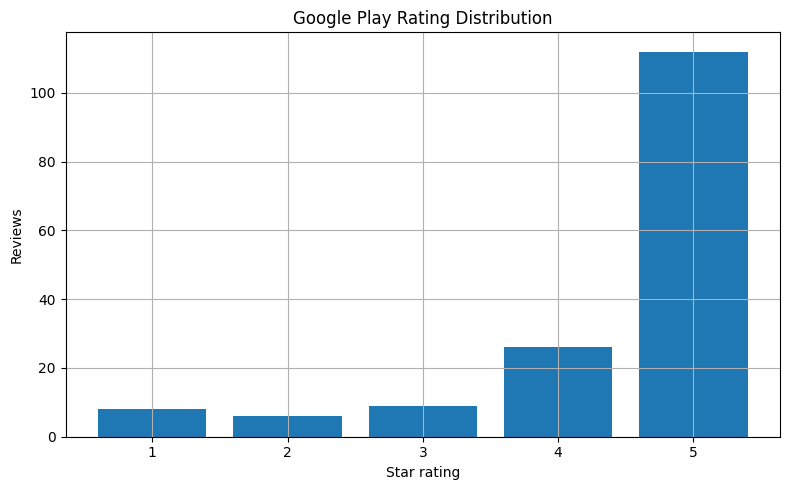

In [13]:
rating_counts = reviews["rating"].value_counts().reindex([1,2,3,4,5], fill_value=0)
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Google Play Rating Distribution")
plt.xlabel("Star rating")
plt.ylabel("Reviews")
plt.tight_layout()
plt.show()

## 11. Sentiment profile

In [14]:
sentiment_summary = (
    reviews.groupby("sentiment", observed=True)
    .agg(
        reviews=("review_id", "count"),
        avg_rating=("rating", "mean"),
        avg_word_count=("word_count", "mean"),
        avg_thumbs_up=("thumbs_up", "mean")
    )
    .reindex(["Positive", "Neutral", "Negative"])
    .round(2)
)
sentiment_summary

,reviews,avg_rating,avg_word_count,avg_thumbs_up
sentiment,,,,
Positive,138,4.81,13.53,1.88
Neutral,9,3.00,41.89,2.00
Negative,14,1.43,28.86,2.57


## 12. Developer response rate by rating

In [15]:
response_by_rating = (
    reviews.groupby("rating")
    .agg(
        reviews=("review_id", "count"),
        responses=("has_developer_response", "sum"),
        response_rate=("has_developer_response", "mean")
    )
)
response_by_rating["response_rate"] = (response_by_rating["response_rate"] * 100).round(1)
response_by_rating

,reviews,responses,response_rate
rating,,,
1,8,8,100.0
2,6,5,83.3
3,9,8,88.9
4,26,11,42.3
5,112,18,16.1


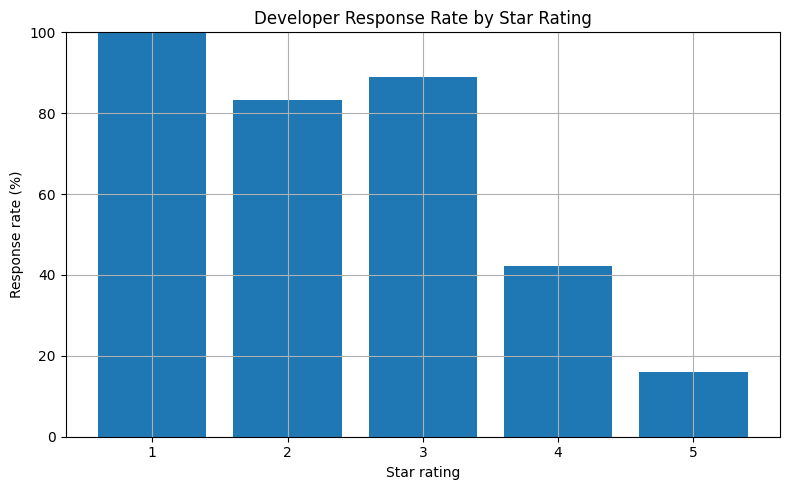

In [16]:
plot_data = response_by_rating.reset_index()
plt.figure(figsize=(8,5))
plt.bar(plot_data["rating"].astype(str), plot_data["response_rate"])
plt.title("Developer Response Rate by Star Rating")
plt.xlabel("Star rating")
plt.ylabel("Response rate (%)")
plt.ylim(0,100)
plt.tight_layout()
plt.show()

From this chart, I can see that lower-rated reviews are more likely to receive a developer response. This suggests that the developer gives more attention to unhappy users.

## 13. Developer response rate by sentiment

In [17]:
response_by_sentiment = (
    reviews.groupby("sentiment", observed=True)
    .agg(
        reviews=("review_id", "count"),
        responses=("has_developer_response", "sum"),
        response_rate=("has_developer_response", "mean"),
        median_delay=("response_delay_days", "median")
    )
    .reindex(["Positive", "Neutral", "Negative"])
)
response_by_sentiment["response_rate"] = (response_by_sentiment["response_rate"] * 100).round(1)
response_by_sentiment.round(2)

,reviews,responses,response_rate,median_delay
sentiment,,,,
Positive,138,29,21.0,1.78
Neutral,9,8,88.9,11.23
Negative,14,13,92.9,183.09


## 14. Response-time distribution and SLA

In [18]:
reviews["response_delay_days"].describe(
    percentiles=[0.25,0.5,0.75,0.9,0.95,0.99]
).to_frame()

,response_delay_days
count,47.000000
mean,133.938475
std,269.335887
min,0.007639
25%,0.238194
50%,6.368056
75%,100.560417
90%,537.878056
95%,712.130139
99%,1074.938708


In [19]:
reviews["response_delay_band"].value_counts(dropna=False)

response_delay_band
NaN              114
Within 1 day      17
Over 180 days     10
31-180 days        8
2-7 days           7
8-30 days          5
Name: count, dtype: int64

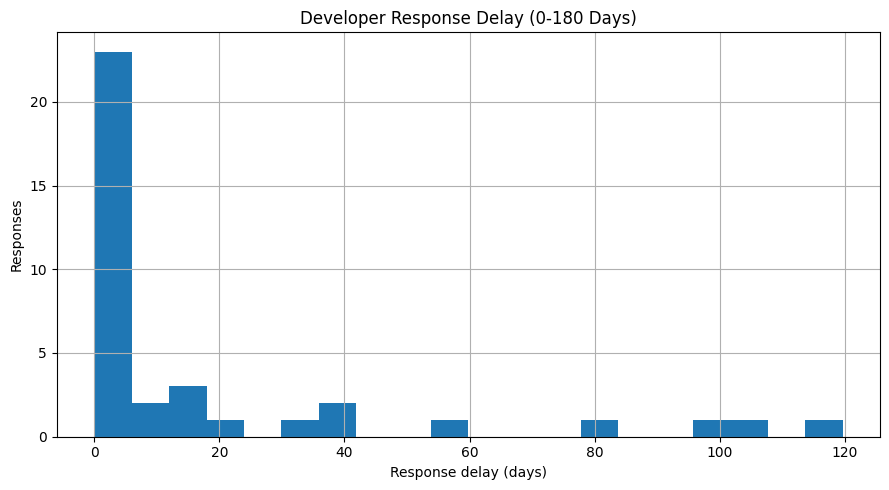

In [20]:
plot_delay = reviews.loc[
    reviews["response_delay_days"].between(0,180, inclusive="both"),
    "response_delay_days"
]
plt.figure(figsize=(9,5))
plt.hist(plot_delay, bins=20)
plt.title("Developer Response Delay (0-180 Days)")
plt.xlabel("Response delay (days)")
plt.ylabel("Responses")
plt.tight_layout()
plt.show()

## 15. Review detail vs sentiment

In [21]:
length_by_sentiment = (
    reviews.groupby("sentiment", observed=True)["word_count"]
    .agg(["count","mean","median","std","max"])
    .reindex(["Positive","Neutral","Negative"])
    .round(2)
)
length_by_sentiment

,count,mean,median,std,max
sentiment,,,,,
Positive,138,13.53,7.5,16.81,94
Neutral,9,41.89,36.0,32.40,97
Negative,14,28.86,28.0,24.73,91


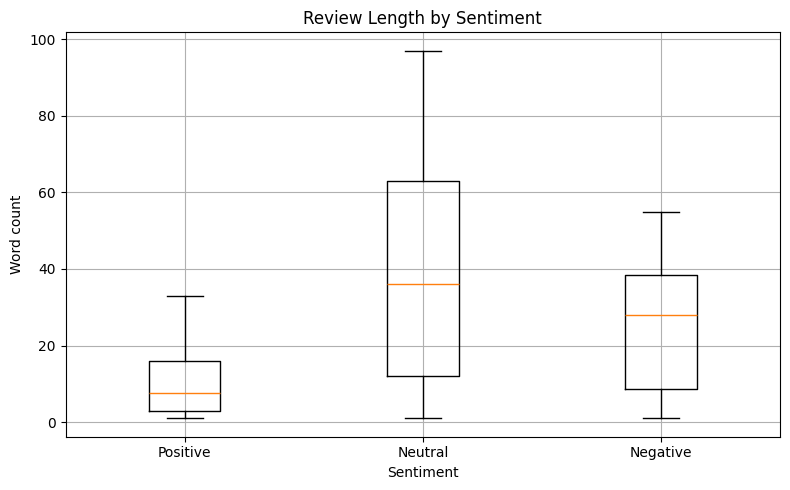

In [22]:
groups = [
    reviews.loc[reviews["sentiment"].eq(label), "word_count"].dropna()
    for label in ["Positive", "Neutral", "Negative"]
]
plt.figure(figsize=(8,5))
plt.boxplot(groups, tick_labels=["Positive", "Neutral", "Negative"], showfliers=False)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word count")
plt.tight_layout()
plt.show()

## 16. Helpful-vote engagement

In [23]:
engagement = (
    reviews.groupby("sentiment", observed=True)["thumbs_up"]
    .agg(["count","mean","median","max"])
    .reindex(["Positive","Neutral","Negative"])
    .round(2)
)
engagement

,count,mean,median,max
sentiment,,,,
Positive,138,1.88,1.0,31
Neutral,9,2.00,2.0,10
Negative,14,2.57,1.0,19


## 17. Review activity through time

In [24]:
yearly = (
    reviews.groupby("review_year")
    .agg(
        reviews=("review_id","count"),
        average_rating=("rating","mean"),
        response_rate=("has_developer_response","mean")
    )
    .reset_index()
)
yearly["response_rate"] *= 100
yearly.round(2)

,review_year,reviews,average_rating,response_rate
0,2016,28,4.14,32.14
1,2017,32,4.69,15.62
2,2018,17,4.65,11.76
3,2019,13,4.77,0.00
4,2020,18,4.33,11.11
5,2021,5,4.40,20.00
6,2022,18,4.00,66.67
7,2023,20,4.40,80.00
8,2024,10,4.40,30.00


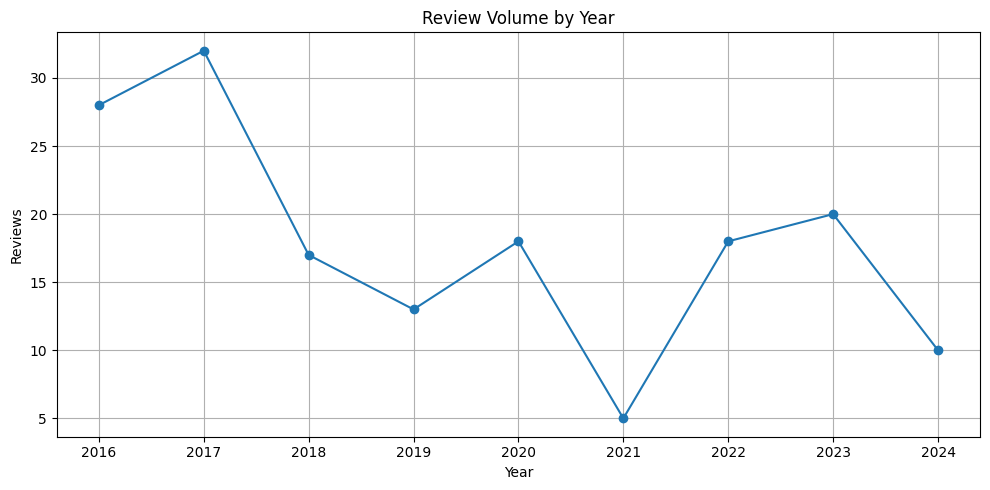

In [25]:
plt.figure(figsize=(10,5))
plt.plot(yearly["review_year"], yearly["reviews"], marker="o")
plt.title("Review Volume by Year")
plt.xlabel("Year")
plt.ylabel("Reviews")
plt.tight_layout()
plt.show()

## 18. Reviews that may have been missed

In [26]:
gap_summary = reviews.loc[
    reviews["unanswered_attention_review"].eq(1),
    ["review_id","rating","thumbs_up","word_count","review_date",
     "priority_score","priority_level"]
].sort_values(["priority_score","thumbs_up"], ascending=False)

print("Unanswered reviews rated 1-3 stars:", len(gap_summary))
gap_summary.head(10)

Unanswered reviews rated 1-3 stars: 2


,review_id,rating,thumbs_up,word_count,review_date,priority_score,priority_level
101,7715fcf6-c017-4edc-8fc4-d23a9daa6999,3,0,63,2017-12-13 22:54:00,84.0,High
149,ac35de02-a5c7-4d9a-9716-4c17d5351736,2,0,7,2016-09-22 02:25:00,82.8,High


These rows represent concrete service-recovery opportunities: customers expressed low or neutral satisfaction but did not receive a recorded developer response.

# Machine learning model

## 19. What I want the model to predict

**Target:** `has_developer_response`

The model estimates whether a historical review receives a developer response.

### Avoiding data leakage

Only information available at or near review submission is used. The following are **excluded from predictors**:

- developer response text,
- developer response date,
- response delay,
- response SLA outcome.

Using those variables would reveal the target and make the model misleadingly strong.

## 20. Define model features

In [27]:
model_features = [
    "review_description",
    "rating",
    "thumbs_up_log",
    "word_count",
    "char_count",
    "exclamation_count",
    "question_count",
    "uppercase_ratio",
    "review_year",
    "review_month_num",
    "is_weekend",
    "app_version_major"
]

X = reviews[model_features].copy()
y = reviews["has_developer_response"]

print("Target distribution:")
print(y.value_counts())
print()
print("Response rate:", round(y.mean(), 3))

Target distribution:
has_developer_response
0    111
1     50
Name: count, dtype: int64

Response rate: 0.311


## 21. Prepare the data for modelling

In [28]:
numeric_features = [
    "rating","thumbs_up_log","word_count","char_count",
    "exclamation_count","question_count","uppercase_ratio",
    "review_year","review_month_num","is_weekend"
]
categorical_features = ["app_version_major"]

def make_preprocessor():
    return ColumnTransformer([
        ("text", TfidfVectorizer(
            ngram_range=(1,2),
            min_df=2,
            max_features=800,
            sublinear_tf=True
        ), "review_description"),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

TF-IDF converts review text into numeric features. Numeric features are standardised for Logistic Regression, while app-version major numbers are one-hot encoded.

## 22. Compare Logistic Regression and Random Forest

In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", estimator)
    ])
    scores = cross_validate(
        pipeline, X, y, cv=cv,
        scoring=["accuracy","precision","recall","f1","roc_auc"]
    )
    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC_AUC": scores["test_roc_auc"].mean()
    })

model_comparison = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False)
model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.826,0.721,0.78,0.738,0.917
1,Random Forest,0.814,0.753,0.62,0.667,0.896


The dataset only has 161 reviews, so I did not want to depend on one train/test split. I used 5-fold stratified cross-validation so that I could compare the models across several splits while keeping a similar response/non-response balance.

## 23. Check the selected model's predictions

In [30]:
selected_model = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("model", LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])

oof_probability = cross_val_predict(
    selected_model, X, y, cv=cv, method="predict_proba"
)[:,1]
oof_prediction = (oof_probability >= 0.5).astype(int)

reviews["predicted_response_probability_oof"] = oof_probability
reviews["predicted_response_class_oof"] = oof_prediction

print("OOF ROC-AUC:", round(roc_auc_score(y, oof_probability), 3))
print()
print(classification_report(y, oof_prediction, digits=3))

OOF ROC-AUC: 0.902

              precision    recall  f1-score   support

           0      0.895     0.847     0.870       111
           1      0.696     0.780     0.736        50

    accuracy                          0.826       161
   macro avg      0.796     0.813     0.803       161
weighted avg      0.833     0.826     0.829       161



## 24. Confusion matrix

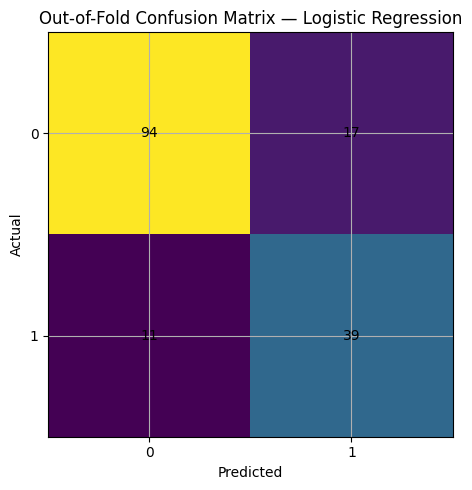

In [31]:
cm = confusion_matrix(y, oof_prediction)

fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(cm)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_title("Out-of-Fold Confusion Matrix — Logistic Regression")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

## 25. Train the final Logistic Regression model

In [32]:
selected_model.fit(X, y)

feature_names = selected_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = selected_model.named_steps["model"].coef_[0]

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_table["absolute_coefficient"] = coef_table["coefficient"].abs()

coef_table.sort_values("absolute_coefficient", ascending=False).head(20)

,feature,coefficient,absolute_coefficient
487,numeric__rating,-1.514767,1.514767
494,numeric__review_year,1.361407,1.361407
504,categorical__app_version_major_7,1.278765,1.278765
500,categorical__app_version_major_18,-1.256045,1.256045
501,categorical__app_version_major_22,1.203204,1.203204
499,categorical__app_version_major_17,-0.694153,0.694153
234,text__love,0.585279,0.585279
47,text__application,0.540381,0.540381
498,categorical__app_version_major_16,0.498631,0.498631
489,numeric__word_count,0.483886,0.483886


I use the Logistic Regression coefficients to get an idea of which features are linked with a higher or lower chance of receiving a response. I do not interpret these relationships as proof that one feature causes the response.

## 26. Look at the easier-to-explain model features

In [33]:
interpretable = coef_table[
    coef_table["feature"].str.startswith(("numeric__", "categorical__"))
].sort_values("absolute_coefficient", ascending=False)

interpretable.head(15)

,feature,coefficient,absolute_coefficient
487,numeric__rating,-1.514767,1.514767
494,numeric__review_year,1.361407,1.361407
504,categorical__app_version_major_7,1.278765,1.278765
500,categorical__app_version_major_18,-1.256045,1.256045
501,categorical__app_version_major_22,1.203204,1.203204
499,categorical__app_version_major_17,-0.694153,0.694153
498,categorical__app_version_major_16,0.498631,0.498631
489,numeric__word_count,0.483886,0.483886
503,categorical__app_version_major_4,-0.436115,0.436115
495,numeric__review_month_num,0.380528,0.380528


## 27. Combine the model with the review-priority analysis

In [34]:
model_gap = reviews.loc[
    reviews["unanswered_attention_review"].eq(1),
    [
        "review_id","rating","thumbs_up","word_count","priority_score",
        "priority_level","predicted_response_probability_oof","review_date"
    ]
].sort_values(
    ["priority_score","predicted_response_probability_oof"],
    ascending=[False, True]
)

model_gap.head(10)

,review_id,rating,thumbs_up,word_count,priority_score,priority_level,predicted_response_probability_oof,review_date
101,7715fcf6-c017-4edc-8fc4-d23a9daa6999,3,0,63,84.0,High,0.971126,2017-12-13 22:54:00
149,ac35de02-a5c7-4d9a-9716-4c17d5351736,2,0,7,82.8,High,0.935160,2016-09-22 02:25:00


For this table, I combine two pieces of information:

- **Priority score:** how strongly the review should attract business attention.
- **Predicted response probability:** how closely the review resembles reviews that historically received responses.

If a review has high priority but no response, I would consider it an important review for the company to check, even if the model gives it a low predicted response probability.

## 28. Save the final model

In [35]:
MODEL_DIR = Path("..") / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    selected_model,
    MODEL_DIR / "developer_response_logistic_regression.joblib"
)
print("Model saved.")

Model saved.


# Prepare the data for Power BI

## 29. Create the Power BI fact table

Reviewer names and raw developer-response text are intentionally omitted from the dashboard export.

In [36]:
powerbi_columns = [
    "review_id","review_description","rating","thumbs_up","review_date",
    "appVersion","language_code","country_code",
    "has_developer_response","response_delay_days","invalid_response_delay",
    "sentiment","needs_attention","word_count","char_count",
    "exclamation_count","question_count","uppercase_ratio","avg_word_length",
    "review_year","review_month_num","review_month_name","review_quarter",
    "review_day_name","is_weekend","thumbs_up_log","review_length_band",
    "engagement_band","app_version_major","response_delay_band",
    "responded_within_7_days","priority_score","priority_level",
    "predicted_response_probability_oof","predicted_response_class_oof",
    "unanswered_attention_review"
]

powerbi_reviews = reviews[powerbi_columns].copy()
powerbi_reviews.head()

,review_id,review_description,rating,thumbs_up,review_date,appVersion,language_code,country_code,has_developer_response,response_delay_days,invalid_response_delay,sentiment,needs_attention,word_count,char_count,exclamation_count,question_count,uppercase_ratio,avg_word_length,review_year,review_month_num,review_month_name,review_quarter,review_day_name,is_weekend,thumbs_up_log,review_length_band,engagement_band,app_version_major,response_delay_band,responded_within_7_days,priority_score,priority_level,predicted_response_probability_oof,predicted_response_class_oof,unanswered_attention_review
0,81942ead-9d65-4b1a-8aa2-6e21ad5cf5e7,"Still loving it!, the best!",5,0,2024-09-03 00:23:00,23.12.04000,en,us,0,NaN,False,Positive,0,5,27,2,0,0.037037,4.600000,2024,9,Sep,Q3,Tuesday,0,0.0,Very short,No votes,23,NaN,NaN,22.0,Low,0.819062,1,0
1,c08cf1e7-45e4-43a3-b86f-51f7809b80a3,Convenient one stop app for all your passwords...,5,0,2024-08-19 03:32:00,23.12.04000,en,us,0,NaN,False,Positive,0,38,189,0,0,0.015873,4.000000,2024,8,Aug,Q3,Monday,0,0.0,Medium,No votes,23,NaN,NaN,35.2,Low,0.933683,1,0
2,c8937763-e1b4-43b1-9e48-cde58be80111,Tried several password managers until I came a...,5,0,2024-07-30 08:07:00,23.12.04000,en,us,0,NaN,False,Positive,0,50,272,0,0,0.025735,4.460000,2024,7,Jul,Q3,Tuesday,0,0.0,Medium,No votes,23,NaN,NaN,40.0,Low,0.961972,1,0
3,762baf4b-9109-4b4b-a42f-2291b0486faf,Ok thank you,5,0,2024-06-11 17:20:00,Unknown,en,us,0,NaN,False,Positive,0,3,12,0,0,0.083333,3.333333,2024,6,Jun,Q2,Tuesday,0,0.0,Very short,No votes,Unknown,NaN,NaN,21.2,Low,0.752707,1,0
4,275a2d36-6d77-44ae-9d7b-8be6ad614e3f,switched phones and none of my passwords came ...,1,0,2024-05-19 19:20:00,23.12.04000,en,us,1,2.1875,False,Negative,1,14,76,0,0,0.000000,4.500000,2024,5,May,Q2,Sunday,1,0.0,Short,No votes,23,2-7 days,1.0,105.6,High,0.997883,1,0


## 30. Export Power BI tables

In [37]:
POWERBI_DIR = Path("..") / "powerbi"
PROCESSED_DIR = Path("..") / "data" / "processed"
OUTPUT_DIR = Path("..") / "outputs"

POWERBI_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

powerbi_reviews.to_csv(
    POWERBI_DIR / "google_play_reviews_powerbi.csv", index=False
)
powerbi_reviews.to_csv(
    PROCESSED_DIR / "google_play_reviews_cleaned.csv", index=False
)

sentiment_export = (
    reviews.groupby("sentiment", observed=True)
    .agg(
        reviews=("review_id","count"),
        avg_rating=("rating","mean"),
        responses=("has_developer_response","sum"),
        response_rate=("has_developer_response","mean"),
        median_response_delay=("response_delay_days","median"),
        avg_word_count=("word_count","mean"),
        avg_thumbs_up=("thumbs_up","mean")
    )
    .reset_index()
)
sentiment_export["response_rate"] *= 100
sentiment_export.to_csv(
    POWERBI_DIR / "sentiment_summary.csv", index=False
)

yearly_export = (
    reviews.groupby("review_year")
    .agg(
        reviews=("review_id","count"),
        avg_rating=("rating","mean"),
        response_rate=("has_developer_response","mean"),
        avg_thumbs_up=("thumbs_up","mean")
    )
    .reset_index()
)
yearly_export["response_rate"] *= 100
yearly_export.to_csv(
    POWERBI_DIR / "yearly_summary.csv", index=False
)

model_comparison.to_csv(
    OUTPUT_DIR / "model_comparison.csv", index=False
)

print("Power BI and model-output tables exported.")

Power BI and model-output tables exported.


# 31. What I learned from the analysis

Based on this dataset:

- The company has **161 reviews** with an average rating of **4.42/5**.
- The overall developer response rate is **31.1%**, meaning most reviews receive no recorded response.
- Response behaviour is strongly related to rating: lower-rated reviews are much more likely to receive a reply than 5-star reviews.
- The median valid response delay is **6.4 days**, while the distribution contains very long delays; therefore median response time is more representative than the mean.
- There are **23 reviews rated 1–3 stars**, of which **2** have no recorded response.
- The best benchmark model is **Logistic Regression**, reaching mean stratified cross-validated ROC-AUC of approximately **0.917**.
- This suggests that review rating, text, timing, engagement and app-version information contain useful signal about historical response behaviour.

## Recommended company actions

1. Introduce a clear response SLA for 1–3 star reviews.
2. Track **response rate**, **median response delay**, and **7-day SLA compliance** as separate KPIs.
3. Use the Power BI dashboard to highlight unanswered high-priority reviews.
4. Investigate changes in support policy across years and app versions.
5. Collect a larger dataset before treating the predictive model as production-ready.
6. Use the model as decision support rather than an automatic response rule.

## Portfolio interpretation

The project demonstrates data cleaning, feature engineering, exploratory analysis, business KPI design, NLP preprocessing, machine-learning pipelines, cross-validation, model evaluation, model interpretation, privacy-aware export design, and BI preparation.

# 32. Limitations of my project

- The dataset contains only 161 observations.
- Ratings are imbalanced toward positive reviews.
- All records have the same language and country code, so those fields cannot explain variation in this sample.
- Historical response patterns may reflect changing support policies rather than stable customer behaviour.
- The response model predicts what historically happened, not what the company *should* do.
- Cross-validation reduces evaluation instability but does not replace external validation.
- Reviewer names should not be exposed unnecessarily in a public portfolio.